Dataset shape: (315, 2)
Unique predictions: [-1  1]
Number of anomalies: 16


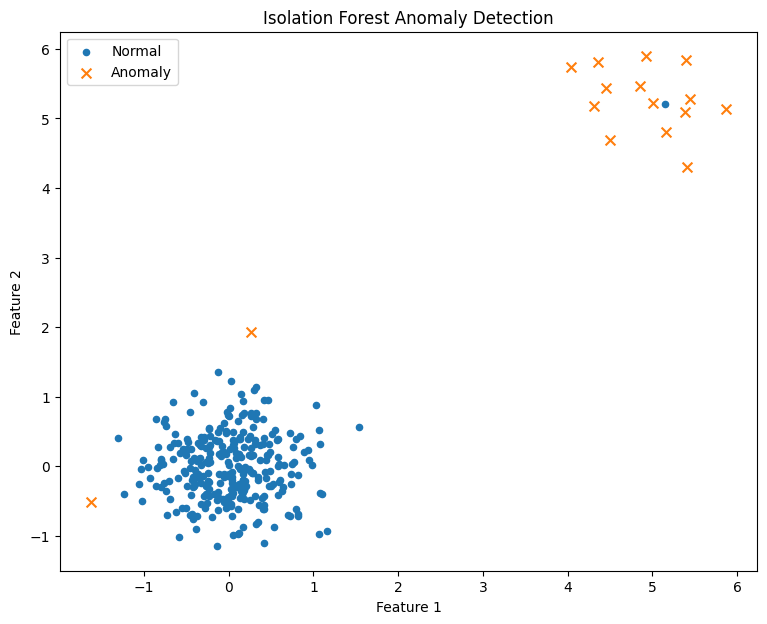

First 10 decision scores:
[0.24156195 0.18331563 0.24235843 0.16820503 0.23270626 0.23895974
 0.14076455 0.16788564 0.21510231 0.17045379]
First 10 sample scores:
[-0.38602853 -0.44427485 -0.38523205 -0.45938545 -0.39488422 -0.38863074
 -0.48682593 -0.45970485 -0.41248817 -0.45713669]
Most anomalous points:
[[5.41447727 4.30507809]
 [4.03622037 5.74424782]
 [5.86423656 5.13026637]
 [4.50359812 4.69139199]
 [5.39330165 5.84499876]
 [4.92401161 5.89456668]
 [4.36319543 5.81690112]
 [5.16678359 4.80170283]
 [4.30670281 5.17245966]
 [4.45850279 5.44450514]]
Their scores:
[-0.72820727 -0.71972138 -0.70626376 -0.70553407 -0.70287822 -0.70245211
 -0.68987289 -0.67587012 -0.66823921 -0.66075437]
New point predictions:
[ 1  1 -1 -1]


In [1]:
# ============================================================
# ISOLATION FOREST — Anomaly Detection
# ============================================================
#
# LEVEL: 🟡 Medium
#
# We will learn:
#   1. Why anomaly detection?
#   2. Intuition
#   3. Internal working
#   4. Important math
#   5. sklearn implementation
#   6. Important parameters
#   7. contamination
#   8. anomaly scores
#   9. Practical example
#  10. Compare with LOF / One-Class SVM
#  11. Interview questions
#  12. Working tree
#
# No need to implement Isolation Forest from scratch.
# Focus on understanding how it works and using sklearn.
# ============================================================


# ============================================================
# 1. WHY ANOMALY DETECTION?
# ============================================================

# Normal classification:
#
#     Input → Class
#
#     Example:
#         email → spam / not spam
#
#
# Anomaly detection is different.
#
# Usually we have:
#
#     LOTS OF NORMAL DATA
#     +
#     VERY FEW / NO KNOWN ANOMALIES
#
#
# Goal:
#
#     Find unusual observations.
#
#
# Examples:
#
#     Fraud detection
#     Network attacks
#     Machine failures
#     Credit-card fraud
#     Sensor failures
#     Manufacturing defects
#     Abnormal transactions
#     Strange user behavior
#
#
# Example:
#
#     Transaction amount
#
#     500
#     700
#     450
#     600
#     550
#     520
#     580
#     50000   ← suspicious
#
#
# 50000 may be an anomaly.
#
# ============================================================


# ============================================================
# 2. TYPES OF ANOMALY DETECTION
# ============================================================

# There are three common settings:
#
#
# 1. POINT ANOMALY
#
#    One individual observation is unusual.
#
#    Example:
#
#       500
#       520
#       490
#       510
#       50000 ← anomaly
#
#
# 2. CONTEXTUAL ANOMALY
#
#    A value is unusual given its context.
#
#    Example:
#
#       Temperature = 30°C
#
#    Normal in summer.
#    Potentially unusual in some winter context.
#
#
# 3. COLLECTIVE ANOMALY
#
#    A group/sequence of observations is abnormal.
#
#    Example:
#
#       Network traffic:
#
#       normal
#       normal
#       normal
#       abnormal sequence
#       abnormal sequence
#       abnormal sequence
#
#
# Isolation Forest mainly targets point anomalies.
#
# ============================================================


# ============================================================
# 3. INTUITION
# ============================================================

# The key idea is surprisingly simple:
#
#
#     ANOMALIES ARE EASIER TO ISOLATE.
#
#
# Imagine:
#
#
# NORMAL DATA:
#
#          ● ● ● ●
#        ● ● ● ● ●
#        ● ● ● ● ●
#          ● ● ●
#
#
# ANOMALY:
#
#                         X
#
#
# If we randomly split the feature space:
#
#     The isolated X may be separated very quickly.
#
#     The dense group takes many splits to isolate
#     individual points.
#
#
# Therefore:
#
#     SHORT PATH → likely anomaly
#
#     LONG PATH  → likely normal
#
#
# This is the central idea of Isolation Forest.
#
# ============================================================


# ============================================================
# 4. WHY IS IT CALLED "ISOLATION FOREST"?
# ============================================================

# "Isolation":
#
#     We try to isolate individual observations.
#
#
# "Forest":
#
#     We build many random isolation trees.
#
#
# Similar high-level idea:
#
#
#          Dataset
#             |
#      -----------------
#      |       |       |
#     Tree1   Tree2   Tree3
#      |       |       |
#     path    path    path
#      |       |       |
#      -----------------
#             |
#             v
#       Average path
#             |
#             v
#      Anomaly score
#
#
# ============================================================


# ============================================================
# 5. INTERNAL WORKING — STEP BY STEP
# ============================================================

# Suppose we have:
#
#     X = [1, 2, 3, 4, 5, 50]
#
# Here:
#
#     50
#
# looks suspicious.
#
#
# ------------------------------------------------------------
# STEP 1 — RANDOMLY SAMPLE DATA
# ------------------------------------------------------------
#
# Isolation Forest usually builds trees using random samples
# of the dataset.
#
#
# ------------------------------------------------------------
# STEP 2 — RANDOMLY SELECT A FEATURE
# ------------------------------------------------------------
#
# Suppose we have multiple features:
#
#     age
#     income
#     transaction_amount
#     frequency
#
#
# A random feature is selected.
#
#
# ------------------------------------------------------------
# STEP 3 — RANDOMLY SELECT A SPLIT VALUE
# ------------------------------------------------------------
#
# Suppose:
#
#     transaction_amount
#
# ranges from:
#
#     100 → 50000
#
#
# A random split may be:
#
#     amount < 1000
#
#
# Data gets divided:
#
#     left:
#         100
#         200
#         500
#
#     right:
#         5000
#         50000
#
#
# ------------------------------------------------------------
# STEP 4 — REPEAT
# ------------------------------------------------------------
#
# Continue randomly splitting each branch.
#
#
# Eventually every observation becomes isolated.
#
#
# Example:
#
#                    amount < 1000?
#                       /       \
#                     YES       NO
#                     /          \
#                  normal       50000
#                               isolated
#
#
# The anomaly gets isolated using fewer splits.
#
#
# ------------------------------------------------------------
# STEP 5 — BUILD MANY TREES
# ------------------------------------------------------------
#
# One tree can be noisy.
#
# Therefore:
#
#     Tree 1
#     Tree 2
#     Tree 3
#     ...
#     Tree 100
#
#
# Each tree uses random choices.
#
#
# ------------------------------------------------------------
# STEP 6 — CALCULATE PATH LENGTH
# ------------------------------------------------------------
#
# For every observation:
#
#     Count how many splits were required
#     to isolate it.
#
#
# Example:
#
#     Point A → 3 splits
#     Point B → 5 splits
#     Point C → 7 splits
#     Point D → 12 splits
#
#
# Point A is easier to isolate.
#
#
# Therefore:
#
#     shorter path
#          ↓
#     more anomalous
#
#
# ============================================================


# ============================================================
# 6. PATH LENGTH
# ============================================================

# Let:
#
#     h(x)
#
# = path length needed to isolate point x.
#
#
# If:
#
#     h(x) = 3
#
# the point was isolated quickly.
#
#
# If:
#
#     h(x) = 15
#
# the point required many splits.
#
#
# Therefore:
#
#     low average path length
#            ↓
#        anomaly
#
#
#     high average path length
#            ↓
#          normal
#
# ============================================================


# ============================================================
# 7. WHY NORMAL POINTS HAVE LONGER PATHS
# ============================================================

# Normal points usually lie inside dense regions.
#
#
# Example:
#
#              ● ● ●
#            ● ● ● ● ●
#            ● ● ● ● ●
#              ● ● ●
#
#
# Random splits keep multiple normal points together.
#
# So it takes many splits to isolate one particular point.
#
#
# Anomaly:
#
#                       X
#
# It is already separated from the dense population.
#
# A random split can isolate it quickly.
#
# ============================================================


# ============================================================
# 8. CORE MATHEMATICS
# ============================================================

# Isolation Forest uses the average path length.
#
#
# Let:
#
#     E[h(x)]
#
# be the average path length of point x
# across all isolation trees.
#
#
# For a subsample of size ψ:
#
#     c(ψ) = 2H(ψ - 1) - 2(ψ - 1)/ψ
#
#
# where:
#
#     H(n) = harmonic number
#
#
# approximately:
#
#     H(n) ≈ ln(n) + γ
#
#
# where:
#
#     γ ≈ 0.5772
#
#
# The anomaly score is conceptually:
#
#
#              E[h(x)]
#     s(x) = 2^(- -------- )
#                 c(ψ)
#
#
# So:
#
#     short path
#         ↓
#     E[h(x)] small
#         ↓
#     s(x) closer to 1
#         ↓
#     more anomalous
#
#
#     long path
#         ↓
#     E[h(x)] large
#         ↓
#     s(x) closer to 0
#         ↓
#     more normal
#
#
# NOTE:
#
# sklearn exposes its own score conventions through
# score_samples() and decision_function().
#
# So don't assume sklearn's raw score_samples value is
# literally the same s(x) formula above.
#
# ============================================================


# ============================================================
# 9. IMPORTANT PARAMETER — n_estimators
# ============================================================

# Number of isolation trees.
#
#
# Example:
#
#     n_estimators=100
#
# means:
#
#     build 100 trees.
#
#
# More trees:
#
#     generally more stable estimates
#
# But:
#
#     more computation.
#
#
# Common starting point:
#
#     100
#     200
#     300
#
# ============================================================


# ============================================================
# 10. IMPORTANT PARAMETER — max_samples
# ============================================================

# Number of samples used to build each tree.
#
#
# Example:
#
#     max_samples=256
#
# means each tree uses up to 256 samples.
#
#
# Why use a subset?
#
# Because Isolation Forest does not need the entire dataset
# in every tree.
#
#
# Smaller sample:
#
#     faster
#     potentially stronger isolation behavior
#
#
# Larger sample:
#
#     more data per tree
#     more computation
#
#
# sklearn default:
#
#     max_samples="auto"
#
# which is typically:
#
#     min(256, n_samples)
#
# ============================================================


# ============================================================
# 11. IMPORTANT PARAMETER — contamination
# ============================================================

# contamination represents the expected proportion of
# anomalies in the dataset.
#
#
# Example:
#
#     contamination=0.05
#
# means:
#
#     approximately 5% of observations are expected to
#     be anomalies.
#
#
# Example:
#
#     10,000 records
#
#     0.05 × 10,000
#
#     = approximately 500 anomalies
#
#
# IMPORTANT:
#
# contamination mainly affects the threshold used to classify
# observations as:
#
#     anomaly
#     normal
#
#
# It does NOT mean:
#
#     "the algorithm magically knows which 5% are truly wrong."
#
#
# You should choose it based on domain knowledge when possible.
#
# ============================================================


# ============================================================
# 12. IMPORTANT PARAMETER — max_features
# ============================================================

# Number/proportion of features considered for each tree.
#
#
# Smaller:
#
#     more randomness
#
#
# Larger:
#
#     more features available
#
#
# Usually the default is sufficient.
#
# ============================================================


# ============================================================
# 13. IMPORTANT PARAMETER — bootstrap
# ============================================================

# Whether samples are drawn with replacement.
#
#
# bootstrap=True:
#
#     sampling with replacement.
#
#
# bootstrap=False:
#
#     sampling without replacement.
#
#
# Isolation Forest already relies heavily on randomization,
# so this is usually not the first parameter to tune.
#
# ============================================================


# ============================================================
# 14. IMPORTANT PARAMETERS SUMMARY
# ============================================================

# n_estimators:
#     Number of isolation trees.
#
# max_samples:
#     Number of samples used per tree.
#
# contamination:
#     Expected anomaly proportion / threshold.
#
# max_features:
#     Number/proportion of features used per tree.
#
# bootstrap:
#     Sampling with or without replacement.
#
# random_state:
#     Reproducibility.
#
# n_jobs:
#     Number of CPU workers.
#
# ============================================================


# ============================================================
# 15. IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest


# ============================================================
# 16. CREATE SIMPLE DATA
# ============================================================

# Normal points around:
#
#     (0, 0)
#
# Anomalies far away.
#

rng = np.random.RandomState(42)

X_normal = 0.5 * rng.randn(300, 2)

X_anomaly = rng.uniform(
    low=4,
    high=6,
    size=(15, 2)
)

X = np.vstack([
    X_normal,
    X_anomaly
])

print("Dataset shape:", X.shape)


# ============================================================
# 17. TRAIN ISOLATION FOREST
# ============================================================

model = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination=0.05,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

model.fit(X)


# ============================================================
# 18. PREDICT NORMAL / ANOMALY
# ============================================================

predictions = model.predict(X)

# sklearn convention:
#
#     +1 → normal
#     -1 → anomaly
#

print("Unique predictions:", np.unique(predictions))

print("Number of anomalies:",
      np.sum(predictions == -1))


# ============================================================
# 19. VISUALIZE RESULTS
# ============================================================

plt.figure(figsize=(9, 7))

plt.scatter(
    X[predictions == 1, 0],
    X[predictions == 1, 1],
    label="Normal",
    s=20
)

plt.scatter(
    X[predictions == -1, 0],
    X[predictions == -1, 1],
    label="Anomaly",
    s=50,
    marker="x"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Isolation Forest Anomaly Detection")
plt.legend()

plt.show()


# ============================================================
# 20. decision_function()
# ============================================================

# decision_function gives a score relative to the learned
# decision threshold.
#
#
# sklearn convention:
#
#     positive → more normal
#
#     negative → more anomalous
#
#
# Points with:
#
#     decision_function < 0
#
# are classified as anomalies by predict().
#

decision_scores = model.decision_function(X)

print("First 10 decision scores:")
print(decision_scores[:10])


# ============================================================
# 21. score_samples()
# ============================================================

# score_samples gives the raw anomaly-related score used
# internally by sklearn.
#
# Important:
#
#     LOWER score
#         ↓
#     more abnormal
#
#
# Do not confuse this with decision_function().
#
sample_scores = model.score_samples(X)

print("First 10 sample scores:")
print(sample_scores[:10])


# ============================================================
# 22. FIND MOST ANOMALOUS POINTS
# ============================================================

# Lower score = more anomalous.
#
# So sort ascending.

most_anomalous_indices = np.argsort(sample_scores)[:10]

print("Most anomalous points:")
print(X[most_anomalous_indices])

print("Their scores:")
print(sample_scores[most_anomalous_indices])


# ============================================================
# 23. NEW DATA
# ============================================================

# We can also detect anomalies in new observations.

new_points = np.array([
    [0.1, 0.2],    # likely normal
    [0.5, -0.3],   # likely normal
    [5.0, 5.0],    # likely anomaly
    [6.0, 4.5]     # likely anomaly
])

new_predictions = model.predict(new_points)

print("New point predictions:")
print(new_predictions)


# ============================================================
# 24. ANOMALY DETECTION WITHOUT LABELS
# ============================================================

# This is one of the main advantages.
#
# We don't need:
#
#     y = [normal, normal, anomaly, ...]
#
#
# Instead:
#
#     X
#     ↓
#     Isolation Forest
#     ↓
#     anomaly / normal
#
#
# Therefore Isolation Forest is commonly used for
# UNSUPERVISED anomaly detection.
#
# ============================================================


# ============================================================
# 25. ISOLATION FOREST vs RANDOM FOREST
# ============================================================

# VERY IMPORTANT INTERVIEW QUESTION.
#
#
# Random Forest:
#
#     Goal:
#         Prediction
#
#     Usually:
#         supervised
#
#     Uses:
#         labeled target y
#
#
# Isolation Forest:
#
#     Goal:
#         Anomaly detection
#
#     Usually:
#         unsupervised
#
#     Main idea:
#         isolate observations
#
#
# Random Forest:
#
#     Trees → classification/regression
#
#
# Isolation Forest:
#
#     Trees → isolation/path length
#
#
# They both use trees and randomness,
# but their objectives are different.
#
# ============================================================


# ============================================================
# 26. ISOLATION FOREST vs K-MEANS
# ============================================================

# K-Means:
#
#     Find cluster centers.
#
#
# Isolation Forest:
#
#     Find observations that are easy to isolate.
#
#
# K-Means asks:
#
#     "Which cluster does this point belong to?"
#
#
# Isolation Forest asks:
#
#     "How unusual is this point?"
#
#
# K-Means requires choosing K.
#
# Isolation Forest does not require number of clusters.
#
# ============================================================


# ============================================================
# 27. ISOLATION FOREST vs LOF
# ============================================================

# Isolation Forest:
#
#     Global isolation-based idea.
#
#     Randomly partitions data.
#
#
# LOF:
#
#     Local density-based idea.
#
#     Compares a point's local density with the density
#     of its neighbors.
#
#
# Example:
#
# A point may look normal globally but abnormal compared
# with its local neighborhood.
#
# LOF can capture this type of local anomaly.
#
#
# Isolation Forest:
#
#     "How quickly can I isolate this point?"
#
#
# LOF:
#
#     "How different is this point's local density
#      from its neighbors?"
#
# ============================================================


# ============================================================
# 28. ISOLATION FOREST vs ONE-CLASS SVM
# ============================================================

# Isolation Forest:
#
#     Random tree partitioning
#
#     Usually easier to scale
#
#
# One-Class SVM:
#
#     Learns a boundary around normal observations
#
#     Kernel-based
#
#
# Mental model:
#
# Isolation Forest:
#
#     isolate unusual points
#
#
# One-Class SVM:
#
#     learn boundary around normal data
#
# ============================================================


# ============================================================
# 29. ADVANTAGES
# ============================================================

# Advantages:
#
#     1. Does not require anomaly labels.
#
#     2. Works well with high-dimensional data.
#
#     3. Relatively efficient.
#
#     4. Handles nonlinear patterns.
#
#     5. No need to calculate explicit distance between
#        every pair of points.
#
#     6. Can handle large datasets reasonably well.
#
#     7. Works naturally with mixed feature scales better
#        than distance-based methods in some settings,
#        although preprocessing can still matter.
#
# ============================================================


# ============================================================
# 30. LIMITATIONS
# ============================================================

# 1. contamination can be difficult to choose.
#
#
# 2. Results can depend on randomization.
#
#
# 3. Not always ideal for contextual or collective anomalies.
#
#
# 4. If anomalies are not isolated from normal observations,
#    detection can be difficult.
#
#
# 5. Feature representation matters.
#
#
# 6. A statistically unusual point is not necessarily
#    a real-world problem.
#
# ============================================================


# ============================================================
# 31. PRACTICAL WORKFLOW
# ============================================================

# Real ML pipeline:
#
#
#     Raw data
#        |
#        v
#     Clean data
#        |
#        v
#     Feature engineering
#        |
#        v
#     Train Isolation Forest
#        |
#        v
#     anomaly score
#        |
#        v
#     Choose threshold
#        |
#        v
#     Flag suspicious observations
#        |
#        v
#     Human/business investigation
#
#
# IMPORTANT:
#
# Anomaly detection should often be treated as
# a screening/ranking mechanism rather than blindly
# deleting every detected point.
#
# ============================================================


# ============================================================
# 32. INTERVIEW QUESTIONS
# ============================================================

# Q1. What is Isolation Forest?
#
# Answer:
#
# Isolation Forest is an unsupervised anomaly-detection
# algorithm that builds random isolation trees. Anomalies
# usually require fewer random splits to isolate, resulting
# in shorter average path lengths.
#
#
# Q2. Why are anomalies easier to isolate?
#
# Answer:
#
# Anomalies are usually sparse and far from dense regions,
# so random partitions can separate them with fewer splits.
#
#
# Q3. Why do we need many trees?
#
# Answer:
#
# A single random tree can be unstable. Averaging isolation
# behavior over many randomized trees gives a more stable
# anomaly estimate.
#
#
# Q4. What does contamination mean?
#
# Answer:
#
# It represents the expected proportion of anomalies and is
# used to determine the threshold for converting anomaly
# scores into anomaly/normal labels.
#
#
# Q5. What does predict() return?
#
# Answer:
#
#     +1 → normal
#     -1 → anomaly
#
#
# Q6. What is the main difference between Isolation Forest
# and Random Forest?
#
# Answer:
#
# Random Forest is primarily a supervised prediction method,
# while Isolation Forest is designed for unsupervised
# anomaly detection using isolation path lengths.
#
#
# Q7. What is the core mathematical idea?
#
# Answer:
#
# Calculate the average path length required to isolate a
# sample across many random trees. Shorter paths indicate
# greater likelihood of being an anomaly.
#
#
# ============================================================
# 33. 30-SECOND INTERVIEW EXPLANATION
# ============================================================

# "Isolation Forest is an unsupervised anomaly detection
# algorithm based on random partitioning. It builds many
# random trees and measures how many splits are needed to
# isolate each observation. Since anomalies are usually
# sparse and easier to separate from the rest of the data,
# they tend to have shorter average path lengths. The
# algorithm converts this isolation behavior into an
# anomaly score and can then flag observations below a
# chosen threshold."
#
#
# ============================================================
# 34. WORKING TREE
# ============================================================

#                    INPUT DATA
#                        |
#                        v
#                Random subsample
#                        |
#                        v
#              Build random tree
#                        |
#                        v
#             Random feature selection
#                        |
#                        v
#              Random split point
#                        |
#                        v
#             Partition observations
#                        |
#                        v
#              Repeat until isolated
#                        |
#                        v
#                 Path length
#                        |
#                        v
#               Build many trees
#                        |
#                        v
#             Average path length
#                        |
#                        v
#                Anomaly score
#                   /          \
#                  /            \
#           Short path        Long path
#               |                 |
#               v                 v
#            ANOMALY            NORMAL
#
#
# ============================================================
# 35. MENTAL MODEL
# ============================================================

# Normal:
#
#       ● ● ● ● ●
#     ● ● ● ● ● ●
#     ● ● ● ● ● ●
#
#     Hard to isolate
#     → long path
#     → normal
#
#
# Anomaly:
#
#                       X
#
#     Easy to isolate
#     → short path
#     → anomaly
#
# ============================================================